In [13]:
# ==============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW 
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef, roc_auc_score, 
    average_precision_score, confusion_matrix, roc_curve, f1_score,
    precision_score, recall_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from safetensors.torch import save_file

# --- CONFIGURATION ---
class Config:
    # Files (Update paths if necessary)
    POSITIVE_CSV = "datasets/fusion_gene_positive_bp_information_with_class_for_modeling.txt"
    NEGATIVE_CSV = "datasets/fusion_gene_negative_bp_information_with_class_for_modeling.txt"
    TEST_CSV = "datasets/fusion_gene_positive_bp_information_with_class_for_testing.txt"
    
    # Extra FASTA Data
    EXTRA_POS_FASTA = "datasets/blast_validated_chimeras.fasta,datasets/cosmic_high_confidence_sequences.fna,datasets/chimeras_43466.fa"
    NEG_FASTA_CANONICAL = "datasets/false_negative_candidates.fasta"
    NEG_FASTA_SYNTHETIC = "datasets/false_positive_candidates.fasta"
    
    # Model & Training
    OUTPUT_DIR = "./hyenadna_v9.9_checkpoints_32k"
    MODEL_NAME = "LongSafari/hyenadna-small-32k-seqlen-hf"
    
    # --- UPDATED FOR 32K CONTEXT ---
    MAX_LEN = 32768  # Full 32k Context
    BATCH_SIZE = 8   
    
    EPOCHS = 3
    LEARNING_RATE = 1e-5
    VAL_SPLIT = 0.2
    SEED = 42
    
    CONFIDENCE_THRESHOLD = 0.85 

if not os.path.exists(Config.OUTPUT_DIR):
    os.makedirs(Config.OUTPUT_DIR)

# --- REPRODUCIBILITY ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup Complete. Device: {device}")

if torch.cuda.is_available():
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✅ Setup Complete. Device: cuda
   GPU Name: NVIDIA A100 80GB PCIe
   Memory: 84.99 GB


In [14]:
# ==============================================================================
# CELL 2: CLASS DEFINITIONS (DataPrep, Dataset, Model)
# ==============================================================================
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoModel

# --- 1. DATA PREPARATOR (Updated with Random Padding) ---
class DataPreparator:
    COLUMNS = ["Hgene","Hchr","Hbp","Hstrand","Tgene","Tchr","Tbp","Tstrand","5'-gene sequence (10Kb)","3'-gene sequence (10Kb)"]

    def __init__(self, config):
        self.cfg = config
        self.trans_table = str.maketrans("ATCGN", "TAGCN")
        self.train_sequences = set()

    def _trim_artifacts(self, sequence: str) -> str:
        if not isinstance(sequence, str): return ""
        return sequence.upper().strip()

    def _get_reverse_complement(self, sequence: str) -> str:
        return sequence.upper().translate(self.trans_table)[::-1]

    def _generate_random_dna(self, length: int) -> str:
        if length <= 0: return ""
        return "".join(random.choices("ACGT", k=length))

    def _apply_jitter(self, seq_5p: str, seq_3p: str) -> str:
        """
        Combines sequences and pads with RANDOM DNA to reach 32k.
        Preserves sequence integrity (no overriding).
        """
        seq_5p = self._trim_artifacts(seq_5p)
        seq_3p = self._trim_artifacts(seq_3p)
        
        # Combine to form core fusion
        core_seq = seq_5p + seq_3p
        core_len = len(core_seq)
        target_len = self.cfg.MAX_LEN
        
        # Case A: Sequence is shorter than 32k -> Pad with Random DNA
        if core_len < target_len:
            needed = target_len - core_len
            jitter = random.randint(-1000, 1000)
            
            pad_left = (needed // 2) + jitter
            pad_right = needed - pad_left
            
            # Safety bounds
            if pad_left < 0: 
                pad_right += pad_left
                pad_left = 0
            if pad_right < 0:
                pad_left += pad_right
                pad_right = 0
                
            left_seq = self._generate_random_dna(pad_left)
            right_seq = self._generate_random_dna(pad_right)
            return left_seq + core_seq + right_seq

        # Case B: Sequence is larger -> Center Crop with Jitter
        else:
            start = (core_len - target_len) // 2
            shift = random.randint(-2000, 2000)
            start += shift
            start = max(0, min(start, core_len - target_len))
            return core_seq[start : start + target_len]

    def _load_fasta(self, path: str) -> list:
        if not os.path.exists(path): return []
        seqs, curr = [], []
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('>'):
                    if curr: seqs.append(self._trim_artifacts("".join(curr)))
                    curr = []
                else: curr.append(line)
            if curr: seqs.append(self._trim_artifacts("".join(curr)))
        return seqs

# --- 2. DATASET CLASS ---
class DNABreakpointDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_len):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = str(self.sequences[idx])
        label = self.labels[idx]
        
        # Tokenization for HyenaDNA (Character level handled by tokenizer)
        enc = self.tokenizer(
            seq, 
            truncation=True, 
            max_length=self.max_len, 
            padding='max_length', 
            return_tensors='pt'
        )
        
        input_ids = enc['input_ids'].squeeze(0)
        
        # Manual attention mask creation if needed
        if 'attention_mask' in enc:
            mask = enc['attention_mask'].squeeze(0)
        else:
            mask = (input_ids != (self.tokenizer.pad_token_id or 0)).long()
            
        return {'input_ids': input_ids, 'attention_mask': mask, 'labels': torch.tensor(label, dtype=torch.long)}

# --- 3. MODEL CLASS (HyenaDNAClassifier) ---
class HyenaDNAClassifier(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        # Load base model
        self.hyena = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Classification Head & Attention Pooling
        self.head = nn.Linear(self.hyena.config.d_model, 1) 
        self.clf = nn.Linear(self.hyena.config.d_model, num_labels)
        
    def forward(self, input_ids, attention_mask=None, labels=None):
        # 1. Get Embeddings
        out = self.hyena(input_ids).last_hidden_state
        
        # 2. Attention/Pooling Mechanism
        scores = self.head(out)
        if attention_mask is not None: 
            scores = scores.masked_fill(attention_mask.unsqueeze(-1) == 0, float('-inf'))
        attn_probs = torch.softmax(scores, dim=1)
        
        # 3. Weighted Pooling
        pooled = torch.sum(out * attn_probs, dim=1)
        
        # 4. Final Classification
        logits = self.clf(pooled)
        
        # 5. Loss Calculation
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            
        # 6. Breakpoint Estimation (Heuristic: Max Attention)
        bp_index = torch.argmax(attn_probs, dim=1).squeeze(-1)
        
        return {'loss': loss, 'logits': logits, 'breakpoint_index': bp_index}

In [15]:
# ==============================================================================
# CELL 3: METRICS & VISUALIZATION LOGIC
# ==============================================================================
def compute_metrics(y_true, y_probs):
    y_pred = np.argmax(y_probs, axis=1)
    
    # --- Standard Metrics ---
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    
    # --- AUC Metrics ---
    try: 
        auroc = roc_auc_score(y_true, y_probs[:, 1])
    except ValueError: 
        auroc = 0.0
        
    return {
        "acc": acc, "mcc": mcc, "f1": f1, "prec": prec, "rec": rec, "auroc": auroc
    }

def plot_comprehensive_results(y_true, y_probs, predicted_bps, title_prefix=""):
    y_pred = np.argmax(y_probs, axis=1)
    y_scores = y_probs[:, 1]
    
    plt.figure(figsize=(14, 10)) 
    
    # A. Confusion Matrix
    plt.subplot(2, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    plt.title(f'{title_prefix} Confusion Matrix')

    # B. ROC Curve
    plt.subplot(2, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_scores):.3f}', color='purple', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.legend()
    plt.title(f'{title_prefix} ROC Curve')

    # C. Probability Distribution
    plt.subplot(2, 2, 3)
    neg_scores = y_scores[y_true == 0]
    pos_scores = y_scores[y_true == 1]
    sns.histplot(neg_scores, color='red', alpha=0.5, label='True Neg', bins=30, kde=True)
    sns.histplot(pos_scores, color='green', alpha=0.5, label='True Pos', bins=30, kde=True)
    plt.axvline(0.5, color='black', linestyle='--')
    plt.legend()
    plt.title(f'{title_prefix} Probability Dist.')

    # D. Genomic Index
    plt.subplot(2, 2, 4)
    high_conf = np.where((y_pred == 1) & (y_scores > Config.CONFIDENCE_THRESHOLD))[0]
    if len(high_conf) > 0:
        sns.histplot(predicted_bps[high_conf], kde=True, bins=50, color='blue', label='Predicted')
        plt.title(f'{title_prefix} Breakpoints (Conf > {Config.CONFIDENCE_THRESHOLD})')
        plt.xlabel('Genomic Index')
    else:
        plt.text(0.5, 0.5, "No High-Confidence Fusions", ha='center')
        plt.title('Breakpoint Locations')

    plt.tight_layout()
    plt.show()

In [16]:
# ==============================================================================
# CELL 4: TRAINING & VALIDATION LOOPS
# ==============================================================================

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_probs, all_labels = [], []
    
    for batch in tqdm(loader, desc="Training"):
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(ids, attention_mask=mask, labels=lbls)
        loss = outputs['loss']
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs['logits'], dim=1)
        
        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(lbls.detach().cpu().numpy())
        
        # Memory Cleanup
        del ids, mask, lbls, outputs, loss
    
    # Clear cache at end of epoch
    if torch.cuda.is_available(): torch.cuda.empty_cache()
        
    metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
    metrics['loss'] = total_loss / len(loader)
    return metrics

def validate(model, loader, device, desc="Validating"):
    model.eval()
    all_probs, all_labels, all_bps = [], [], []
    val_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['labels'].to(device)
            
            outputs = model(ids, attention_mask=mask, labels=lbls)
            val_loss += outputs['loss'].item()
            
            probs = torch.softmax(outputs['logits'], dim=1)
            bps = outputs['breakpoint_index']
            
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(lbls.detach().cpu().numpy())
            all_bps.extend(bps.detach().cpu().numpy())
            
            del ids, mask, lbls, outputs
            
    metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
    metrics['loss'] = val_loss / len(loader)
    return metrics, np.array(all_labels), np.array(all_probs), np.array(all_bps)

In [17]:
# ==============================================================================
# CELL 5: LOAD ALL DATA & PERFORM 3-WAY SPLIT (Full Stats & Granular Dedup)
# ==============================================================================
print("\n--- 1. LOADING ALL DATA ---")
preparator = DataPreparator(Config)

# Track lengths for statistics
all_pos_lengths = []
all_neg_lengths = []

# =======================================================
# A. LOAD POSITIVES (CSV + FASTA)
# =======================================================
pos_dfs = []

# 1. Load Positive CSV
if os.path.exists(Config.POSITIVE_CSV):
    try:
        print(f"  > Loading Positive CSV: {Config.POSITIVE_CSV}")
        csv_df = pd.read_csv(Config.POSITIVE_CSV, header=None, names=DataPreparator.COLUMNS, sep='\t')
        
        # Stats (Raw Lengths)
        raw_lens = (
            csv_df["5'-gene sequence (10Kb)"].astype(str).str.strip().str.len() + 
            csv_df["3'-gene sequence (10Kb)"].astype(str).str.strip().str.len()
        )
        all_pos_lengths.extend(raw_lens.tolist())

        # Process
        csv_df['sequence'] = csv_df.apply(
            lambda r: preparator._apply_jitter(r["5'-gene sequence (10Kb)"], r["3'-gene sequence (10Kb)"]), 
            axis=1
        )
        csv_df['label'] = 1
        pos_dfs.append(csv_df)
        print(f"    - Loaded {len(csv_df)} samples from CSV.")
    except Exception as e:
        print(f"    ⚠️ Error reading Positive CSV: {e}")
else:
    print(f"  ⚠️ POSITIVE CSV missing: {Config.POSITIVE_CSV}")

# 2. Extra FASTA Positives
if hasattr(Config, 'EXTRA_POS_FASTA') and Config.EXTRA_POS_FASTA:
    print("  > Loading Extra FASTA Positives...")
    extra_seqs = []
    for p in Config.EXTRA_POS_FASTA.split(','):
        p = p.strip()
        if p and os.path.exists(p):
            loaded_raw = preparator._load_fasta(p)
            all_pos_lengths.extend([len(s) for s in loaded_raw]) # Stats
            
            processed = [preparator._apply_jitter(s, "") for s in loaded_raw]
            extra_seqs.extend(processed)
            print(f"    - Loaded {len(processed)} from {os.path.basename(p)}")
        elif p:
            print(f"    ⚠️ FASTA file not found: {p}")

    if extra_seqs:
        pos_dfs.append(pd.DataFrame({'sequence': extra_seqs, 'label': 1}))

# Combine & Dedup Positives
if pos_dfs:
    pos_df = pd.concat(pos_dfs, ignore_index=True)
    n_before = len(pos_df)
    pos_df.drop_duplicates(subset=['sequence'], inplace=True)
    n_after = len(pos_df)
    if n_before > n_after:
        print(f"    ⚠️ Removed {n_before - n_after} duplicate sequences within POSITIVES.")
else:
    pos_df = pd.DataFrame(columns=['sequence', 'label'])

# --- POSITIVE STATS PRINT ---
if all_pos_lengths:
    avg_len = sum(all_pos_lengths) / len(all_pos_lengths)
    over_32k = sum(1 for x in all_pos_lengths if x > Config.MAX_LEN)
    print(f"\n📊 POSITIVE DATA STATISTICS:")
    print(f"   - Total: {len(all_pos_lengths)}")
    print(f"   - Avg Length: {avg_len:.0f} bp | Max: {max(all_pos_lengths)} bp | Min: {min(all_pos_lengths)} bp")
    print(f"   - Seqs > 32k (Cropped): {over_32k} ({over_32k/len(all_pos_lengths):.1%})")
    print(f"   - Seqs < 32k (Padded):  {len(all_pos_lengths) - over_32k} ({(len(all_pos_lengths) - over_32k)/len(all_pos_lengths):.1%})\n")

# =======================================================
# B. LOAD NEGATIVES (CSV + FASTA)
# =======================================================
neg_dfs = []

# 1. Negative CSV
if os.path.exists(Config.NEGATIVE_CSV):
    try:
        print(f"  > Loading Negative CSV: {Config.NEGATIVE_CSV}")
        neg_csv = pd.read_csv(Config.NEGATIVE_CSV, header=None, names=DataPreparator.COLUMNS, sep='\t')
        
        # Stats (Raw Lengths)
        raw_lens_neg = (
            neg_csv["5'-gene sequence (10Kb)"].astype(str).str.strip().str.len() + 
            neg_csv["3'-gene sequence (10Kb)"].astype(str).str.strip().str.len()
        )
        all_neg_lengths.extend(raw_lens_neg.tolist())

        # Process
        neg_csv['sequence'] = neg_csv.apply(
            lambda r: preparator._apply_jitter(r["5'-gene sequence (10Kb)"], r["3'-gene sequence (10Kb)"]), 
            axis=1
        )
        neg_csv['label'] = 0
        neg_dfs.append(neg_csv)
        print(f"    - Loaded {len(neg_csv)} samples from CSV.")
    except Exception as e:
        print(f"    ⚠️ Error reading Negative CSV: {e}")

# 2. FASTA Negatives
neg_fasta_sources = [Config.NEG_FASTA_CANONICAL, Config.NEG_FASTA_SYNTHETIC]
for p in neg_fasta_sources:
    if os.path.exists(p):
        print(f"  > Loading Negative FASTA: {os.path.basename(p)}")
        raw_negs = preparator._load_fasta(p)
        
        all_neg_lengths.extend([len(s) for s in raw_negs]) # Stats
        
        processed_negs = [preparator._apply_jitter(s, "") for s in raw_negs]
        neg_dfs.append(pd.DataFrame({'sequence': processed_negs, 'label': 0}))

# Combine & Dedup Negatives
if neg_dfs:
    neg_df = pd.concat(neg_dfs, ignore_index=True)
    
    # Augment (RC)
    print("  > Augmenting Negatives (Reverse Complement)...")
    aug_df = neg_df.copy()
    aug_df['sequence'] = aug_df['sequence'].apply(preparator._get_reverse_complement)
    neg_df = pd.concat([neg_df, aug_df], ignore_index=True)
    
    # Dedup Negatives
    n_before = len(neg_df)
    neg_df.drop_duplicates(subset=['sequence'], inplace=True)
    n_after = len(neg_df)
    if n_before > n_after:
        print(f"    ⚠️ Removed {n_before - n_after} duplicate sequences within NEGATIVES.")
else:
    neg_df = pd.DataFrame(columns=['sequence', 'label'])

# --- NEGATIVE STATS PRINT ---
if all_neg_lengths:
    avg_len = sum(all_neg_lengths) / len(all_neg_lengths)
    over_32k = sum(1 for x in all_neg_lengths if x > Config.MAX_LEN)
    print(f"\n📊 NEGATIVE DATA STATISTICS:")
    print(f"   - Total: {len(all_neg_lengths)}")
    print(f"   - Avg Length: {avg_len:.0f} bp | Max: {max(all_neg_lengths)} bp | Min: {min(all_neg_lengths)} bp")
    print(f"   - Seqs > 32k (Cropped): {over_32k} ({over_32k/len(all_neg_lengths):.1%})")
    print(f"   - Seqs < 32k (Padded):  {len(all_neg_lengths) - over_32k} ({(len(all_neg_lengths) - over_32k)/len(all_neg_lengths):.1%})\n")

# =======================================================
# C. MERGE, FINAL DEDUP, SPLIT
# =======================================================
if pos_df.empty and neg_df.empty:
    raise ValueError("❌ CRITICAL: No data loaded! Check file paths.")

full_df = pd.concat([pos_df[['sequence', 'label']], neg_df[['sequence', 'label']]], ignore_index=True)
initial_len = len(full_df)

# Deduplication (Global)
full_df.drop_duplicates(subset=['sequence'], inplace=True)
print(f"  > Final Global Deduplication: Removed {initial_len - len(full_df)} duplicates (Cross-contamination).")

# Final Shuffle
full_df = full_df.sample(frac=1, random_state=Config.SEED).reset_index(drop=True)

print(f"✅ TOTAL UNIQUE POOL: {len(full_df)} samples")
print(f"   Positives: {sum(full_df['label'] == 1)}")
print(f"   Negatives: {sum(full_df['label'] == 0)}")

# --- 3-WAY SPLIT ---
from sklearn.model_selection import train_test_split

if len(full_df) > 10:
    train_val_df, test_df = train_test_split(
        full_df, test_size=0.15, stratify=full_df['label'], random_state=Config.SEED
    )
    train_df, val_df = train_test_split(
        train_val_df, test_size=0.1765, stratify=train_val_df['label'], random_state=Config.SEED
    )

    print(f"\n--- SPLIT STATISTICS ---")
    print(f"TRAIN Set: {len(train_df)} (Pos: {sum(train_df['label'])})")
    print(f"VAL   Set: {len(val_df)} (Pos: {sum(val_df['label'])})")
    print(f"TEST  Set: {len(test_df)} (Pos: {sum(test_df['label'])})")
else:
    print("⚠️ Not enough data to perform split.")


--- 1. LOADING ALL DATA ---
  > Loading Positive CSV: datasets/fusion_gene_positive_bp_information_with_class_for_modeling.txt


    - Loaded 30745 samples from CSV.
  > Loading Extra FASTA Positives...
    - Loaded 6435 from blast_validated_chimeras.fasta
    - Loaded 13279 from cosmic_high_confidence_sequences.fna
    - Loaded 43466 from chimeras_43466.fa

📊 POSITIVE DATA STATISTICS:
   - Total: 93925
   - Avg Length: 7905 bp | Max: 34308 bp | Min: 101 bp
   - Seqs > 32k (Cropped): 1 (0.0%)
   - Seqs < 32k (Padded):  93924 (100.0%)

  > Loading Negative CSV: datasets/fusion_gene_negative_bp_information_with_class_for_modeling.txt
    - Loaded 20000 samples from CSV.
  > Loading Negative FASTA: false_negative_candidates.fasta
  > Loading Negative FASTA: false_positive_candidates.fasta
  > Augmenting Negatives (Reverse Complement)...

📊 NEGATIVE DATA STATISTICS:
   - Total: 50609
   - Avg Length: 8507 bp | Max: 34350 bp | Min: 500 bp
   - Seqs > 32k (Cropped): 2 (0.0%)
   - Seqs < 32k (Padded):  50607 (100.0%)

  > Final Global Deduplication: Removed 0 duplicates (Cross-contamination).
✅ TOTAL UNIQUE POOL: 19514

--- DATASET STATISTICS ---
Training Set:   136594 samples
  ├── Positives: 65745 (48.1%)
  └── Negatives: 70849 (51.9%)
Validation Set: 29277 samples
  ├── Positives: 14091 (48.1%)
  └── Negatives: 15186 (51.9%)

Init Tokenizer & Model: LongSafari/hyenadna-small-32k-seqlen-hf



 Training Start (3 Epochs)...

--- Epoch 1 ---


Training: 100%|██████████| 17075/17075 [3:33:24<00:00,  1.33it/s]  


TRAIN >> Loss: 0.2388 | Acc: 0.9304 | F1: 0.9274 | AUC: 0.9837


Validating: 100%|██████████| 3660/3660 [22:17<00:00,  2.74it/s]


...

VAL   >> Loss: 0.2384 | Acc: 0.9401 | F1: 0.9365 | AUC: 0.9890

--- Epoch 3 ---


Training: 100%|██████████| 17075/17075 [3:34:39<00:00,  1.33it/s]  


TRAIN >> Loss: 0.2071 | Acc: 0.9483 | F1: 0.9463 | AUC: 0.9908


Validating: 100%|██████████| 3660/3660 [22:27<00:00,  2.72it/s]


VAL   >> Loss: 0.2291 | Acc: 0.9443 | F1: 0.9422 | AUC: 0.9898

--- Plotting VALIDATION Results ---


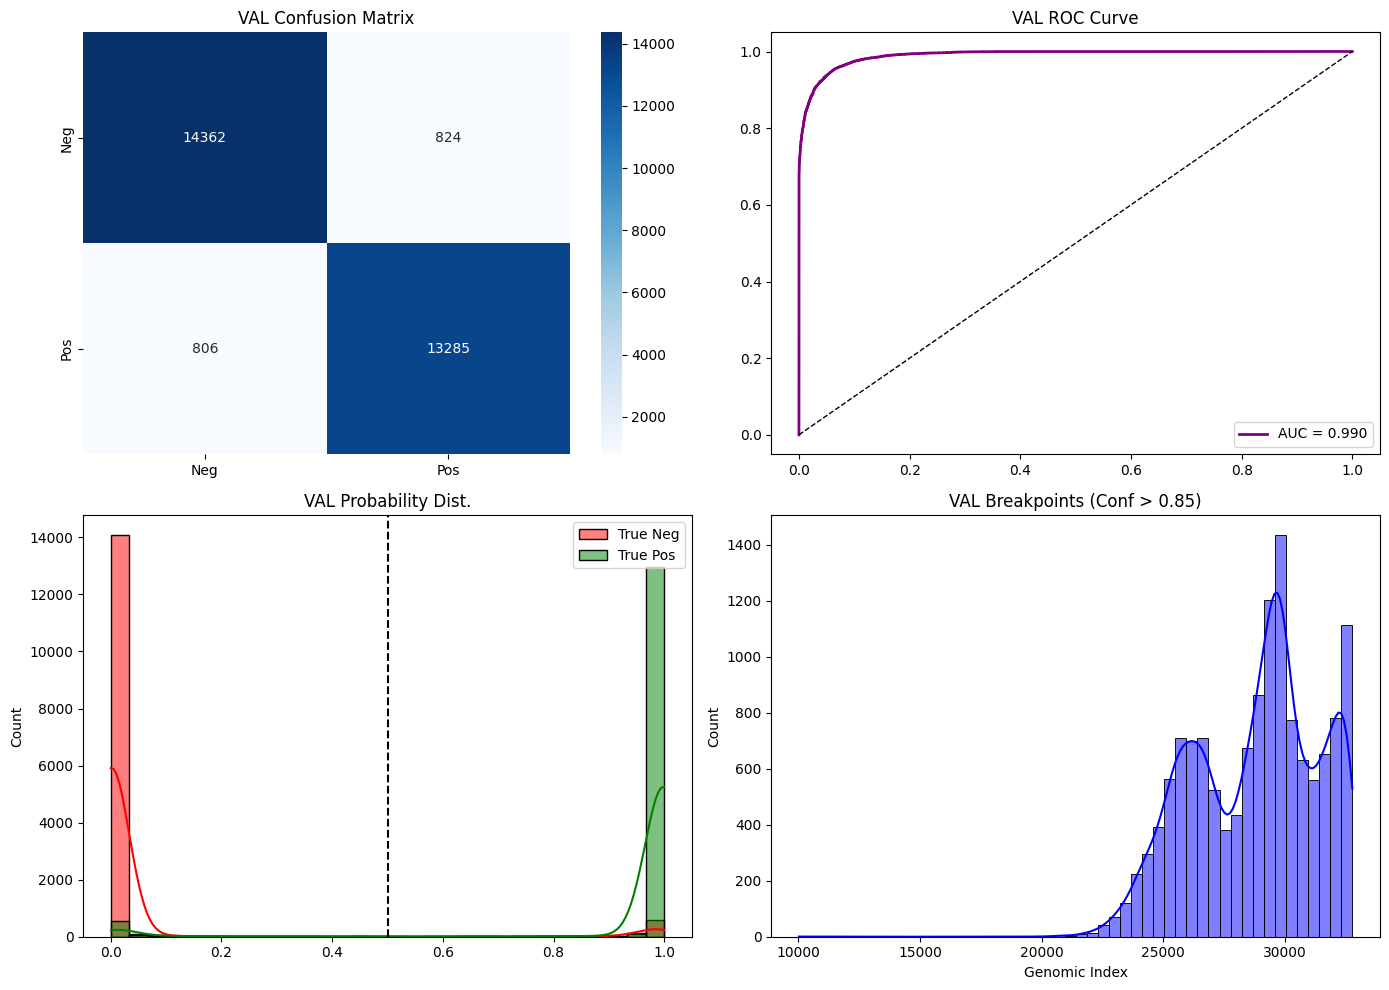


 Saving Final Model to: ./hyenadna_v9.9_checkpoints_32k/final_model
   > Model weights saved.
✅ Save Complete.


In [18]:
# ==============================================================================
# CELL 6: INITIALIZE & TRAIN MODEL (Fixed Safetensors Saving)
# ==============================================================================
from safetensors.torch import save_file 

# 1. ensure labels are available
train_seqs_list = train_df['sequence'].tolist()
train_lbls_list = train_df['label'].tolist()
val_seqs_list = val_df['sequence'].tolist()
val_lbls_list = val_df['label'].tolist()

# 2. Print Stats
n_train_pos = sum(train_lbls_list)
n_train_neg = len(train_lbls_list) - n_train_pos
n_val_pos = sum(val_lbls_list)
n_val_neg = len(val_lbls_list) - n_val_pos

print(f"--- DATASET STATISTICS ---")
print(f"Training Set:   {len(train_lbls_list)} samples")
print(f"  ├── Positives: {n_train_pos} ({n_train_pos/len(train_lbls_list):.1%})")
print(f"  └── Negatives: {n_train_neg} ({n_train_neg/len(train_lbls_list):.1%})")
print(f"Validation Set: {len(val_lbls_list)} samples")
print(f"  ├── Positives: {n_val_pos} ({n_val_pos/len(val_lbls_list):.1%})")
print(f"  └── Negatives: {n_val_neg} ({n_val_neg/len(val_lbls_list):.1%})")

# 3. Init Model
print(f"\nInit Tokenizer & Model: {Config.MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME, trust_remote_code=True)
model = HyenaDNAClassifier(Config.MODEL_NAME).to(device)

# 4. Loaders
train_loader = DataLoader(
    DNABreakpointDataset(train_seqs_list, train_lbls_list, tokenizer, Config.MAX_LEN), 
    batch_size=Config.BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    DNABreakpointDataset(val_seqs_list, val_lbls_list, tokenizer, Config.MAX_LEN), 
    batch_size=Config.BATCH_SIZE, shuffle=False
)

# 5. Optimizer
optimizer = AdamW(model.parameters(), lr=Config.LEARNING_RATE)
scheduler = get_linear_schedule_with_warmup(optimizer, 0, len(train_loader)*Config.EPOCHS)

# 6. Training Loop
print(f"\n Training Start ({Config.EPOCHS} Epochs)...")
for epoch in range(Config.EPOCHS):
    print(f"\n--- Epoch {epoch+1} ---")
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"TRAIN >> Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['acc']:.4f} | F1: {train_metrics['f1']:.4f} | AUC: {train_metrics['auroc']:.4f}")
    
    # Validate
    val_metrics, y_true, y_probs, y_bps = validate(model, val_loader, device)
    print(f"VAL   >> Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f} | AUC: {val_metrics['auroc']:.4f}")
    
    # Save Epoch Checkpoint (Standard PyTorch handles shared tensors fine)
    torch.save(model.state_dict(), f"{Config.OUTPUT_DIR}/model_epoch_{epoch+1}.pt")

print("\n--- Plotting VALIDATION Results ---")
plot_comprehensive_results(y_true, y_probs, y_bps, title_prefix="VAL")

# 7. SAVE FINAL MODEL (Safetensors Format)
print(f"\n Saving Final Model to: {Config.OUTPUT_DIR}/final_model")
final_dir = os.path.join(Config.OUTPUT_DIR, "final_model")
os.makedirs(final_dir, exist_ok=True)

# A. Save Weights (Safetensors)
# FIX: Clone tensors to break shared memory links (fixes RuntimeError)
state_dict = model.state_dict()
clean_state_dict = {k: v.clone().contiguous() for k, v in state_dict.items()}

try:
    save_file(clean_state_dict, os.path.join(final_dir, "model.safetensors"))
    print("   > Model weights saved.")
except Exception as e:
    print(f"   ⚠️ Safetensors save failed: {e}")
    print("   > Fallback: Saving as standard pytorch .bin")
    torch.save(state_dict, os.path.join(final_dir, "pytorch_model.bin"))

# B. Save Tokenizer
tokenizer.save_pretrained(final_dir)

# C. Save Config (Base Hyena Config)
model.hyena.config.save_pretrained(final_dir)

print("✅ Save Complete.")

PHASE 9: BLIND TEST SET EVALUATION
--- TEST SET STATISTICS ---
Total Samples:   29272
  ├── Positives: 14089 (48.1%)
  └── Negatives: 15183 (51.9%)


Testing: 100%|██████████| 3659/3659 [22:29<00:00,  2.71it/s]



🏆 FINAL TEST RESULTS:
   Accuracy:  0.9472
   Precision: 0.9400
   Recall:    0.9509
   F1 Score:  0.9454
   AUC:       0.9904
   MCC:       0.8943


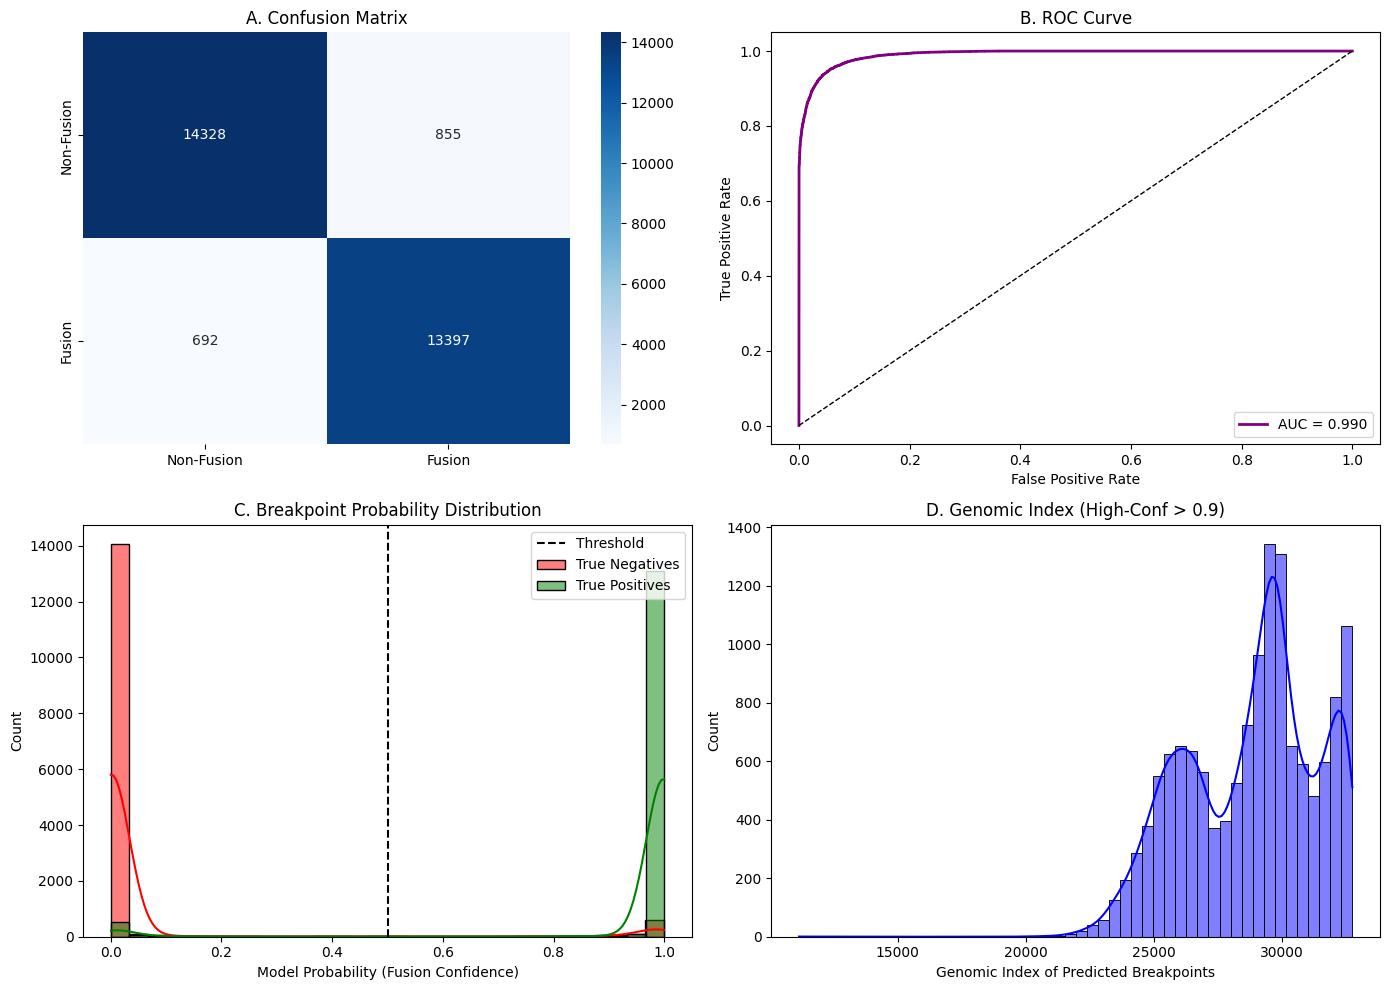


💾 EXPORTING RESULTS...
✅ Predictions successfully saved to: blind_test_predictions_20251215_205248.csv
   (Contains columns: True_Label, Predicted_Label, Fusion_Prob, Result_Type)


In [19]:
# ==============================================================================
# CELL 7: BLIND TEST SET EVALUATION
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from torch.utils.data import DataLoader
from datetime import datetime

print(f"{'='*40}")
print(f"PHASE 9: BLIND TEST SET EVALUATION")
print(f"{'='*40}")

# 1. VISUALIZATION FUNCTION
def plot_test_results_detailed(y_true, y_probs, predicted_bps):
    y_pred = np.argmax(y_probs, axis=1)
    y_scores = y_probs[:, 1] # Probability of being Positive (Fusion)
    
    plt.figure(figsize=(14, 10)) # Large 2x2 Grid
    
    # --- A. Confusion Matrix ---
    plt.subplot(2, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Fusion', 'Fusion'], 
                yticklabels=['Non-Fusion', 'Fusion'])
    plt.title('A. Confusion Matrix')

    # --- B. ROC Curve ---
    plt.subplot(2, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_scores):.3f}', color='purple', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title('B. ROC Curve')

    # --- C. Breakpoint Probability (Confidence Distribution) ---
    plt.subplot(2, 2, 3)
    # Separate scores for True Negatives and True Positives
    neg_scores = y_scores[y_true == 0]
    pos_scores = y_scores[y_true == 1]
    
    sns.histplot(neg_scores, color='red', alpha=0.5, label='True Negatives', bins=30, kde=True)
    sns.histplot(pos_scores, color='green', alpha=0.5, label='True Positives', bins=30, kde=True)
    plt.axvline(0.5, color='black', linestyle='--', label='Threshold')
    plt.xlabel('Model Probability (Fusion Confidence)')
    plt.legend()
    plt.title('C. Breakpoint Probability Distribution')

    # --- D. Genomic Index (Breakpoint Locations) ---
    plt.subplot(2, 2, 4)
    # Filter: Only show locations for High-Confidence Predictions (> 0.9)
    # Ensure Config is available; if not, default to 0.9
    threshold = getattr(Config, 'HIGH_CONF_THRESHOLD', 0.9)
    high_conf_indices = np.where((y_pred == 1) & (y_scores > threshold))[0]
    
    if len(high_conf_indices) > 0:
        valid_bps = predicted_bps[high_conf_indices]
        sns.histplot(valid_bps, kde=True, bins=50, color='blue', label='Predicted Breakpoints')
        plt.xlabel('Genomic Index of Predicted Breakpoints')
        plt.title(f'D. Genomic Index (High-Conf > {threshold})')
    else:
        plt.text(0.5, 0.5, "No High-Confidence Fusions Found", ha='center')
        plt.title('D. Genomic Index (No Data)')

    plt.tight_layout()
    plt.show()

# 2. STATISTICS
# Use the pre-split Test DataFrame (test_df) created in Cell 5
if 'test_df' not in locals():
    print("⚠️ Error: 'test_df' is not defined. Please run Cell 5 first.")
else:
    test_labels = test_df['label'].tolist()
    n_test_pos = sum(test_labels)
    n_test_neg = len(test_labels) - n_test_pos

    print(f"--- TEST SET STATISTICS ---")
    print(f"Total Samples:   {len(test_labels)}")
    print(f"  ├── Positives: {n_test_pos} ({n_test_pos/len(test_labels):.1%})")
    print(f"  └── Negatives: {n_test_neg} ({n_test_neg/len(test_labels):.1%})")

    # 3. PREPARE LOADER
    # Note: shuffling is False for testing to ensure labels align with test_df
    test_loader = DataLoader(
        DNABreakpointDataset(test_df['sequence'].tolist(), test_labels, tokenizer, Config.MAX_LEN), 
        batch_size=Config.BATCH_SIZE, 
        shuffle=False
    )

    # 4. RUN VALIDATION LOGIC
    test_metrics, t_true, t_probs, t_bps = validate(model, test_loader, device, desc="Testing")

    # 5. PRINT RESULTS
    print(f"\n🏆 FINAL TEST RESULTS:")
    print(f"   Accuracy:  {test_metrics['acc']:.4f}")
    print(f"   Precision: {test_metrics['prec']:.4f}")
    print(f"   Recall:    {test_metrics['rec']:.4f}")
    print(f"   F1 Score:  {test_metrics['f1']:.4f}")
    print(f"   AUC:       {test_metrics['auroc']:.4f}")
    print(f"   MCC:       {test_metrics['mcc']:.4f}")

    # 6. VISUALIZE
    plot_test_results_detailed(t_true, t_probs, t_bps)

    # 7. SAVE RESULTS TO CSV
    # ==============================================================================
    print(f"\n💾 EXPORTING RESULTS...")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_filename = f"blind_test_predictions_{timestamp}.csv"

    # Create a DataFrame using the original test_df to preserve metadata (like IDs/Sequences)
    results_df = test_df.copy()

    # Calculate class predictions from probabilities
    # t_probs is typically [N, 2], we take the index of the max value
    pred_classes = np.argmax(t_probs, axis=1)
    pred_scores_fusion = t_probs[:, 1]

    # Append Model Outputs to the DataFrame
    results_df['True_Label'] = t_true
    results_df['Predicted_Label'] = pred_classes
    results_df['Fusion_Prob'] = pred_scores_fusion
    results_df['Predicted_Breakpoint'] = t_bps

    # Add a 'Result_Type' column for easy Excel filtering (TP, FP, TN, FN)
    results_df['Result_Type'] = results_df.apply(
        lambda x: 'TP' if (x['True_Label'] == 1 and x['Predicted_Label'] == 1) else
                  ('TN' if (x['True_Label'] == 0 and x['Predicted_Label'] == 0) else
                  ('FP' if (x['True_Label'] == 0 and x['Predicted_Label'] == 1) else 'FN')),
        axis=1
    )

    # Save to CSV
    results_df.to_csv(csv_filename, index=False)
    print(f"✅ Predictions successfully saved to: {csv_filename}")
    print(f"   (Contains columns: True_Label, Predicted_Label, Fusion_Prob, Result_Type)")